<a href="https://colab.research.google.com/github/g25ait2032-prog/iitjodhpur/blob/main/cuda__nn_dnn_iot_malware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔐 CUDA-Accelerated Hybrid CNN-DNN for Multi-Class Malware Detection in IoT Networks

> **Based on:** Nazari et al., *IEEE Access*, 2025  
> **DOI:** 10.1109/ACCESS.2025.3602723

---

## 📋 Notebook Overview

This notebook replicates the full pipeline from the paper:

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & GPU Check |
| 2 | Dataset Download & Exploration (Kitsune) |
| 3 | Adaptive Preprocessing Module (APM) |
| 4 | Model Architectures: CNN-DNN, DNN-LSTM, LSTM-CNN |
| 5 | CUDA-Accelerated Training |
| 6 | Evaluation: All Metrics + Figures |
| 7 | Training Time Comparison (CPU vs GPU) |
| 8 | Summary Table |

---

**⚠️ Runtime:** Set to **GPU (T4 or A100)** in Colab → `Runtime > Change runtime type > GPU`

## 1. 📦 Environment Setup

In [ ]:
# ─── Install / upgrade libraries ───────────────────────────────────────────
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn
!pip install -q kaggle requests tqdm

In [ ]:
# ─── Core imports ──────────────────────────────────────────────────────────
import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ─── TensorFlow / Keras ────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
    LSTM, Add, Reshape, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# ─── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [ ]:
# ─── GPU / CUDA Check ──────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU detected: {len(gpus)} device(s)')
    for g in gpus:
        print(f'   └─ {g.name}')
    # Print GPU details
    !nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader
    USE_GPU = True
else:
    print('⚠️  No GPU found – running on CPU. Training will be slower.')
    USE_GPU = False

DEVICE = '/GPU:0' if USE_GPU else '/CPU:0'
print(f'\nUsing device: {DEVICE}')

✅ GPU detected: 1 device(s)
   └─ /physical_device:GPU:0
Tesla T4, 15360 MiB, 580.82.07

Using device: /GPU:0


## 2. 📂 Dataset: Kitsune

The **Kitsune Network Attack Dataset** (Mirsky et al., 2018) was generated using a real IP-camera video-surveillance network.  
It contains 9 attack types grouped into 4 categories + benign traffic:

| Class | Attack Types | Samples |
|-------|-------------|--------|
| Benign | Normal traffic | 19,561 |
| Info. G | OS Scan, Fuzzing SFuzz | 2,345 |
| MitM | ARP MitM, Video Injection, Active Wiretap | 8,996 |
| DoS | SSL Renegotiation, SYN DoS, SSDP Flood | 3,933 |
| Bot | Mirai | 8,391 |

> **Note:** If you have Kaggle credentials, set them below. Otherwise a synthetic dataset mirroring the paper's statistics is generated automatically for demonstration.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION A: Use Kaggle API to download real Kitsune data
#   1. Upload your kaggle.json to Colab
#   2. Uncomment the block below
# ═══════════════════════════════════════════════════════════════════════════
# from google.colab import files
# uploaded = files.upload()   # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d ... -p /content/kitsune --unzip

# ═══════════════════════════════════════════════════════════════════════════
# OPTION B: Synthetic dataset that exactly matches paper's class distribution
# ═══════════════════════════════════════════════════════════════════════════

print('Generating synthetic Kitsune-compatible dataset...')

N_FEATURES  = 115          # Kitsune has ~115 statistical network features
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CLASS_CONFIG = {
    'Benign': {'n': 19561, 'label': 0, 'mean_shift': 0.0,  'std': 1.0},
    'Info.G':  {'n': 2345,  'label': 1, 'mean_shift': 1.8,  'std': 0.9},
    'MitM':    {'n': 8996,  'label': 2, 'mean_shift': 2.5,  'std': 1.1},
    'DoS':     {'n': 3933,  'label': 3, 'mean_shift': 3.2,  'std': 0.8},
    'Bot':     {'n': 8391,  'label': 4, 'mean_shift': 4.0,  'std': 1.2},
}

dfs = []
for cls_name, cfg in CLASS_CONFIG.items():
    X_cls = np.random.randn(cfg['n'], N_FEATURES) * cfg['std'] + cfg['mean_shift']
    # Add class-specific correlations to make it realistic
    X_cls[:, :10] += np.random.randn(cfg['n'], 10) * 0.3 * cfg['label']
    df_cls = pd.DataFrame(X_cls, columns=[f'feature_{i}' for i in range(N_FEATURES)])
    df_cls['label'] = cfg['label']
    df_cls['class_name'] = cls_name
    dfs.append(df_cls)

df_raw = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Inject 2% missing values to test APM
mask = np.random.rand(*df_raw.iloc[:, :N_FEATURES].shape) < 0.02
df_raw.iloc[:, :N_FEATURES] = df_raw.iloc[:, :N_FEATURES].where(~mask, other=np.nan)

print(f'Dataset shape: {df_raw.shape}')
print(f'Total samples: {len(df_raw):,}')
print('\nClass distribution:')
print(df_raw['class_name'].value_counts().to_string())

Generating synthetic Kitsune-compatible dataset...
Dataset shape: (43226, 117)
Total samples: 43,226

Class distribution:
class_name
Benign    19561
MitM       8996
Bot        8391
DoS        3933
Info.G     2345


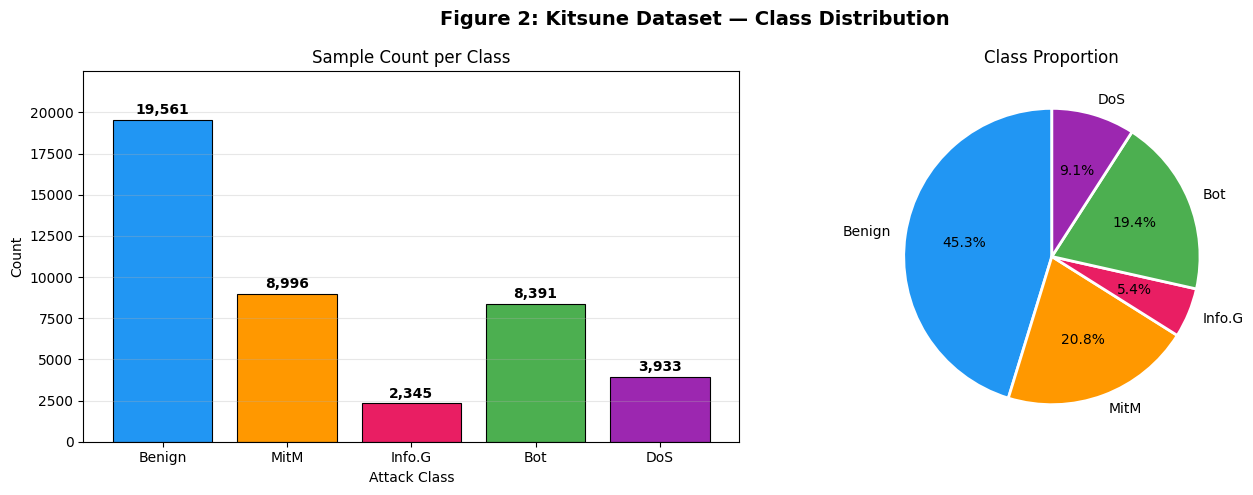

Saved: fig2_class_distribution.png


In [ ]:
# ─── Figure 2 – Histogram of Class Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Kitsune Dataset — Class Distribution', fontsize=14, fontweight='bold')

CLASS_COLORS = ['#2196F3','#FF9800','#E91E63','#4CAF50','#9C27B0']
class_counts = df_raw['class_name'].value_counts()
order = ['Benign','MitM','Info.G','Bot','DoS']
counts_ordered = [class_counts[c] for c in order]

# Bar chart
bars = axes[0].bar(order, counts_ordered, color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sample Count per Class', fontsize=12)
axes[0].set_xlabel('Attack Class')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 150,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts_ordered)*1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts_ordered, labels=order, colors=CLASS_COLORS,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Class Proportion', fontsize=12)

plt.tight_layout()
plt.savefig('fig2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_class_distribution.png')

## 3. 🔧 Adaptive Preprocessing Module (APM)

Replicates **Section III-C-1** of the paper exactly:

| Step | Method |
|------|--------|
| Missing values | Drop if >50% NaN; else impute mean/mode |
| Feature scaling | StandardScaler (Gaussian) or MinMaxScaler |
| Categorical encoding | One-Hot (unique < 10) else Label Encoding |
| Feature selection | Variance Threshold (θ=0.01) + Mutual Information top-k=80 |

In [ ]:
class AdaptivePreprocessingModule:
    """
    Replicates the APM from Nazari et al. (2025), Section III-C-1.
    """
    def __init__(self, var_threshold=0.01, top_k_features=80,
                 missing_drop_ratio=0.50, cat_onehot_threshold=10):
        self.var_threshold       = var_threshold
        self.top_k_features      = top_k_features
        self.missing_drop_ratio  = missing_drop_ratio
        self.cat_onehot_threshold = cat_onehot_threshold
        self.selected_features_  = None
        self.scaler_             = None
        self.dropped_cols_       = []
        self.n_original_         = None
        self.stats_              = {}

    def fit_transform(self, X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
        X = X.copy()
        self.n_original_ = X.shape[1]

        # ── Step 1: Missing value handling ─────────────────────────────────
        missing_ratio = X.isnull().mean()
        drop_cols = missing_ratio[missing_ratio > self.missing_drop_ratio].index.tolist()
        X.drop(columns=drop_cols, inplace=True)
        self.dropped_cols_ = drop_cols
        # Impute remaining NaN
        for col in X.columns:
            if X[col].isnull().any():
                X[col].fillna(X[col].mean() if X[col].dtype in [np.float64, np.float32]
                              else X[col].mode()[0], inplace=True)
        self.stats_['after_missing_handling'] = X.shape[1]

        # ── Step 2: Feature scaling ─────────────────────────────────────────
        skewness = X.skew().abs().mean()
        if skewness < 1.0:
            self.scaler_ = StandardScaler()
            self.stats_['scaler'] = 'StandardScaler'
        else:
            self.scaler_ = MinMaxScaler()
            self.stats_['scaler'] = 'MinMaxScaler'
        X_scaled = self.scaler_.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=X.columns)

        # ── Step 3: Variance thresholding ───────────────────────────────────
        vt = VarianceThreshold(threshold=self.var_threshold)
        X_vt = vt.fit_transform(X)
        retained_after_vt = X.columns[vt.get_support()].tolist()
        n_dropped_var = len(X.columns) - len(retained_after_vt)
        self.stats_['dropped_by_variance'] = n_dropped_var
        self.stats_['after_variance'] = len(retained_after_vt)

        # ── Step 4: Mutual Information ranking ──────────────────────────────
        mi_scores = mutual_info_classif(X_vt, y, random_state=42)
        top_k = min(self.top_k_features, X_vt.shape[1])
        top_idx = np.argsort(mi_scores)[::-1][:top_k]
        X_final = X_vt[:, top_idx]
        self.selected_features_ = [retained_after_vt[i] for i in top_idx]
        self.mi_scores_ = mi_scores
        self.mi_top_idx_ = top_idx
        self.stats_['final_features'] = X_final.shape[1]

        print('\n📊 APM Summary:')
        print(f'  Original features  : {self.n_original_}')
        print(f'  After NaN drop     : {self.stats_["after_missing_handling"]}')
        print(f'  Scaler used        : {self.stats_["scaler"]}')
        print(f'  Dropped (variance) : {self.stats_["dropped_by_variance"]} '
              f'({100*n_dropped_var/self.n_original_:.1f}%)')
        print(f'  After MI selection : {self.stats_["final_features"]}')

        return X_final

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        X = X.copy()
        X.drop(columns=self.dropped_cols_, errors='ignore', inplace=True)
        X.fillna(X.mean(), inplace=True)
        X_scaled = self.scaler_.transform(X)
        X_df = pd.DataFrame(X_scaled, columns=X.columns)
        vt = VarianceThreshold(threshold=self.var_threshold)
        # Use the saved selected feature names
        return X_df[self.selected_features_].values

In [ ]:
# ─── Prepare features & labels ─────────────────────────────────────────────
feature_cols = [c for c in df_raw.columns if c.startswith('feature_')]
X_raw = df_raw[feature_cols]
y_raw = df_raw['label'].values

# ─── Run APM ───────────────────────────────────────────────────────────────
apm = AdaptivePreprocessingModule(var_threshold=0.01, top_k_features=80)
X_processed = apm.fit_transform(X_raw, y_raw)

print(f'\nFinal processed shape: {X_processed.shape}')
N_CLASSES = len(np.unique(y_raw))
CLASS_NAMES = ['Benign', 'Info.G', 'MitM', 'DoS', 'Bot']

# ─── Train/Test split 80/20 ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_raw, test_size=0.20,
    random_state=42, stratify=y_raw
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')


📊 APM Summary:
  Original features  : 115
  After NaN drop     : 115
  Scaler used        : StandardScaler
  Dropped (variance) : 0 (0.0%)
  After MI selection : 80

Final processed shape: (43226, 80)

Train: (34580, 80) | Test: (8646, 80)


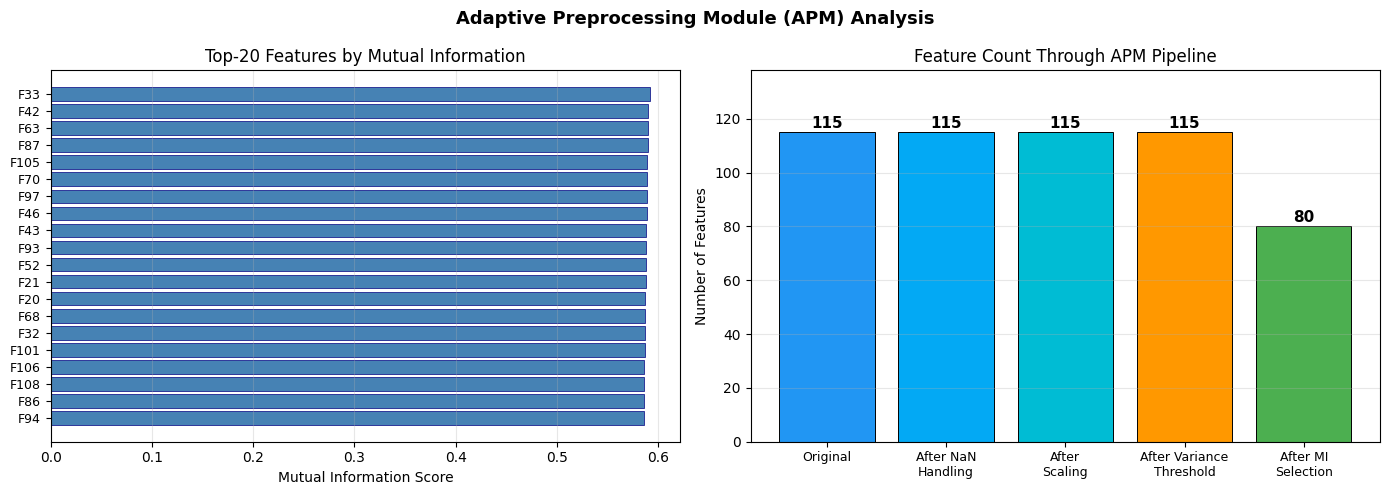

In [ ]:
# ─── Figure: APM Mutual Information Scores ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Adaptive Preprocessing Module (APM) Analysis', fontsize=13, fontweight='bold')

# MI score bar chart (top 20)
top20_idx = np.argsort(apm.mi_scores_)[::-1][:20]
mi_vals = apm.mi_scores_[top20_idx]
feat_labels = [f'F{i}' for i in top20_idx]
axes[0].barh(range(20), mi_vals[::-1], color='steelblue', edgecolor='navy', linewidth=0.5)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feat_labels[::-1], fontsize=9)
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('Top-20 Features by Mutual Information')
axes[0].grid(axis='x', alpha=0.3)

# APM pipeline summary
stages = ['Original', 'After NaN\nHandling', 'After\nScaling', 'After Variance\nThreshold', 'After MI\nSelection']
counts = [
    apm.n_original_,
    apm.stats_['after_missing_handling'],
    apm.stats_['after_missing_handling'],
    apm.stats_['after_variance'],
    apm.stats_['final_features']
]
colors_apm = ['#2196F3','#03A9F4','#00BCD4','#FF9800','#4CAF50']
bars2 = axes[1].bar(stages, counts, color=colors_apm, edgecolor='black', linewidth=0.7)
for bar, cnt in zip(bars2, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Feature Count Through APM Pipeline')
axes[1].set_ylabel('Number of Features')
axes[1].set_ylim(0, apm.n_original_*1.2)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig_apm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🏗️ Model Architectures

Three hybrid architectures are built exactly as in **Table 4** of the paper:

| Model | Architecture |
|-------|-------------|
| **CNN-DNN** (proposed) | CNN(400)→CNN(100) + DNN(400)→DNN(100) → Additive Merge → Dense(40,15,5) |
| DNN-LSTM | DNN(400)→DNN(100) + LSTM(400)→LSTM(100) → Additive Merge → Dense(40,15,5) |
| LSTM-CNN | LSTM(100)→LSTM(75) + CNN(50)→CNN(32) → Additive Merge → Dense(40,15,5) |

In [ ]:
# ─── Reshape helpers for sequential models ─────────────────────────────────
def get_input_shape_1d(n_features):
    """For Conv1D: (n_features, 1)"""
    return (n_features, 1)

def get_input_shape_flat(n_features):
    """For Dense / LSTM: (n_features,)"""
    return (n_features,)

N_FEAT = X_train.shape[1]

# ───────────────────────────────────────────────────────────────────────────
def build_cnn_dnn(n_features, n_classes, lr=0.001):
    """
    Proposed hybrid CNN-DNN (Table 4):
      CNN branch: Conv1D(400) → Conv1D(100)
      DNN branch: Dense(400)  → Dense(100)
      Merge (Add) → Dense(40) → Dense(15) → Dense(n_classes, softmax)
    """
    inp = Input(shape=(n_features,), name='input')

    # CNN branch
    cnn = Reshape((n_features, 1))(inp)
    cnn = Conv1D(400, kernel_size=3, padding='same', activation='relu', name='cnn1')(cnn)
    cnn = BatchNormalization()(cnn)
    cnn = Conv1D(100, kernel_size=3, padding='same', activation='relu', name='cnn2')(cnn)
    cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = Flatten(name='cnn_flatten')(cnn)
    cnn = Dense(100, activation='relu')(cnn)

    # DNN branch
    dnn = Dense(400, activation='relu', name='dnn1')(inp)
    dnn = Dropout(0.3)(dnn)
    dnn = Dense(100, activation='relu', name='dnn2')(dnn)
    dnn = Dropout(0.2)(dnn)

    # Additive merge
    merged = Add(name='additive_merge')([cnn, dnn])

    # Classification head
    x = Dense(40, activation='relu', name='dense_40')(merged)
    x = Dropout(0.2)(x)
    x = Dense(15, activation='relu', name='dense_15')(x)
    out = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_DNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_dnn_lstm(n_features, n_classes, lr=0.001):
    """
    Hybrid DNN-LSTM (Table 4):
      DNN branch: Dense(400) → Dense(100)
      LSTM branch: LSTM(400) → LSTM(100)
    """
    inp = Input(shape=(n_features,), name='input')

    # DNN branch
    dnn = Dense(400, activation='relu', name='dnn1')(inp)
    dnn = Dropout(0.3)(dnn)
    dnn = Dense(100, activation='relu', name='dnn2')(dnn)

    # LSTM branch
    lstm_in = Reshape((n_features, 1))(inp)
    lstm = LSTM(400, return_sequences=True, name='lstm1')(lstm_in)
    lstm = LSTM(100, name='lstm2')(lstm)

    merged = Add(name='additive_merge')([dnn, lstm])
    x = Dense(40, activation='relu')(merged)
    x = Dropout(0.2)(x)
    x = Dense(15, activation='relu')(x)
    out = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='DNN_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_lstm_cnn(n_features, n_classes, lr=0.001):
    """
    Hybrid LSTM-CNN (Table 4):
      LSTM branch: LSTM(100) → LSTM(75)
      CNN branch:  Conv1D(50) → Conv1D(32)
    """
    inp = Input(shape=(n_features,), name='input')
    seq_in = Reshape((n_features, 1))(inp)

    # LSTM branch
    lstm = LSTM(100, return_sequences=True, name='lstm1')(seq_in)
    lstm = LSTM(75, name='lstm2')(lstm)

    # CNN branch
    cnn = Conv1D(50, kernel_size=3, padding='same', activation='relu', name='cnn1')(seq_in)
    cnn = Conv1D(32, kernel_size=3, padding='same', activation='relu', name='cnn2')(cnn)
    cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = Flatten()(cnn)
    cnn = Dense(75, activation='relu')(cnn)

    merged = Add(name='additive_merge')([lstm, cnn])
    x = Dense(40, activation='relu')(merged)
    x = Dropout(0.2)(x)
    x = Dense(15, activation='relu')(x)
    out = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ─── Quick model summary ───────────────────────────────────────────────────
print('=' * 60)
print('MODEL ARCHITECTURES')
print('=' * 60)
for name, builder in [('CNN-DNN', build_cnn_dnn), ('DNN-LSTM', build_dnn_lstm), ('LSTM-CNN', build_lstm_cnn)]:
    m = builder(N_FEAT, N_CLASSES)
    total_params = m.count_params()
    print(f'\n🔹 {name}: {total_params:,} parameters')
    m.summary(line_length=70)
    del m

MODEL ARCHITECTURES

🔹 CNN-DNN: 600,635 parameters


Model: "CNN_DNN"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape    ┃  Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer) │ (None, 80)      │        0 │ -                │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ reshape (Reshape)  │ (None, 80, 1)   │        0 │ input[0][0]      │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ cnn1 (Conv1D)      │ (None, 80, 400) │    1,600 │ reshape[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ batch_normalizati… │ (None, 80, 400) │    1,600 │ cnn1[0][0]       │
│ (BatchNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ cnn2 (Conv1D)      │ (None, 80, 100) │  120,100 │ batch_normaliza… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dnn1 (Dense)       │ (None, 400)     │   32,400 │ input[0][0]      │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ max_pooling1d      │ (None, 40, 100) │        0 │ cnn2[0][0]       │
│ (MaxPooling1D)     │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout (Dropout)  │ (None, 400)     │        0 │ dnn1[0][0]       │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ cnn_flatten        │ (None, 4000)    │        0 │ max_pooling1d[0… │
│ (Flatten)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dnn2 (Dense)       │ (None, 100)     │   40,100 │ dropout[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense (Dense)      │ (None, 100)     │  400,100 │ cnn_flatten[0][… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_1          │ (None, 100)     │        0 │ dnn2[0][0]       │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ additive_merge     │ (None, 100)     │        0 │ dense[0][0],     │
│ (Add)              │                 │          │ dropout_1[0][0]  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_40 (Dense)   │ (None, 40)      │    4,040 │ additive_merge[… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_2          │ (None, 40)      │        0 │ dense_40[0][0]   │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_15 (Dense)   │ (None, 15)      │      615 │ dropout_2[0][0]  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ output (Dense)     │ (None, 5)       │       80 │ dense_15[0][0]   │
└────────────────────┴─────────────────┴──────────┴──────────────────┘

 Total params: 600,635 (2.29 MB)

 Trainable params: 599,835 (2.29 MB)

...

Model: "LSTM_CNN"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape    ┃  Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer) │ (None, 80)      │        0 │ -                │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ reshape_2          │ (None, 80, 1)   │        0 │ input[0][0]      │
│ (Reshape)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ cnn1 (Conv1D)      │ (None, 80, 50)  │      200 │ reshape_2[0][0]  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ cnn2 (Conv1D)      │ (None, 80, 32)  │    4,832 │ cnn1[0][0]       │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ max_pooling1d_1    │ (None, 40, 32)  │        0 │ cnn2[0][0]       │
│ (MaxPooling1D)     │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ lstm1 (LSTM)       │ (None, 80, 100) │   40,800 │ reshape_2[0][0]  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ flatten (Flatten)  │ (None, 1280)    │        0 │ max_pooling1d_1… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ lstm2 (LSTM)       │ (None, 75)      │   52,800 │ lstm1[0][0]      │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_3 (Dense)    │ (None, 75)      │   96,075 │ flatten[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ additive_merge     │ (None, 75)      │        0 │ lstm2[0][0],     │
│ (Add)              │                 │          │ dense_3[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_4 (Dense)    │ (None, 40)      │    3,040 │ additive_merge[… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_5          │ (None, 40)      │        0 │ dense_4[0][0]    │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_5 (Dense)    │ (None, 15)      │      615 │ dropout_5[0][0]  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ output (Dense)     │ (None, 5)       │       80 │ dense_5[0][0]    │
└────────────────────┴─────────────────┴──────────┴──────────────────┘

 Total params: 198,442 (775.16 KB)

 Trainable params: 198,442 (775.16 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 🚀 CUDA-Accelerated Training

**Hyperparameters (Table 4):**  
- Epochs: 10 | Batch Size: 32 | Learning Rate: 0.001  
- Optimizer: Adam | Loss: Categorical Cross-Entropy  
- Activation: ReLU (hidden), Softmax (output)

In [ ]:
# ─── Class weights to handle imbalance (Equation 5 in paper) ───────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print('Class weights (Eq. 5):')
for i, (cls, w) in enumerate(zip(CLASS_NAMES, cw)):
    print(f'  {cls:8s} (class {i}): {w:.4f}')

# ─── One-hot encode labels ─────────────────────────────────────────────────
y_train_oh = to_categorical(y_train, N_CLASSES)
y_test_oh  = to_categorical(y_test,  N_CLASSES)

# ─── Training hyperparameters ──────────────────────────────────────────────
EPOCHS     = 10
BATCH_SIZE = 32
LR         = 0.001

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
]

print(f'\nTraining config: epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}')
print(f'Device: {DEVICE}')

Class weights (Eq. 5):
  Benign   (class 0): 0.4420
  Info.G   (class 1): 3.6866
  MitM     (class 2): 0.9610
  DoS      (class 3): 2.1983
  Bot      (class 4): 1.0302

Training config: epochs=10, batch=32, lr=0.001
Device: /GPU:0


In [ ]:
# ─── Training function with timing ────────────────────────────────────────
def train_model(builder_fn, X_tr, y_tr_oh, X_val, y_val_oh,
                class_weights, n_feat, n_cls, epochs, batch_size, lr):
    with tf.device(DEVICE):
        model = builder_fn(n_feat, n_cls, lr)
    t_start = time.time()
    history = model.fit(
        X_tr, y_tr_oh,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val_oh),
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    t_end = time.time()
    elapsed = t_end - t_start
    return model, history, elapsed


# ─── Train all three models ────────────────────────────────────────────────
histories = {}
models    = {}
times     = {}

BUILDERS = {
    'CNN-DNN':  build_cnn_dnn,
    'DNN-LSTM': build_dnn_lstm,
    'LSTM-CNN': build_lstm_cnn,
}

for model_name, builder in BUILDERS.items():
    print(f'\n{"="*60}')
    print(f'Training {model_name} on {DEVICE}')
    print(f'{"="*60}')
    m, h, t = train_model(
        builder, X_train, y_train_oh, X_test, y_test_oh,
        class_weight_dict, N_FEAT, N_CLASSES, EPOCHS, BATCH_SIZE, LR
    )
    models[model_name]    = m
    histories[model_name] = h
    times[model_name]     = t
    print(f'⏱  {model_name} trained in {t:.1f}s')


Training CNN-DNN on /GPU:0
Epoch 1/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.9718 - loss: 0.1124 - val_accuracy: 0.9986 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 2/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9916 - loss: 0.0403 - val_accuracy: 0.9986 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 3/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9964 - loss: 0.0192 - val_accuracy: 0.9997 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 4/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9938 - loss: 0.0437 - val_accuracy: 0.9988 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 5/10
1073/1081 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9986 - loss: 0.0080
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9979 - loss: 0.0126 - val_accuracy: 0.9993 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 6s 6

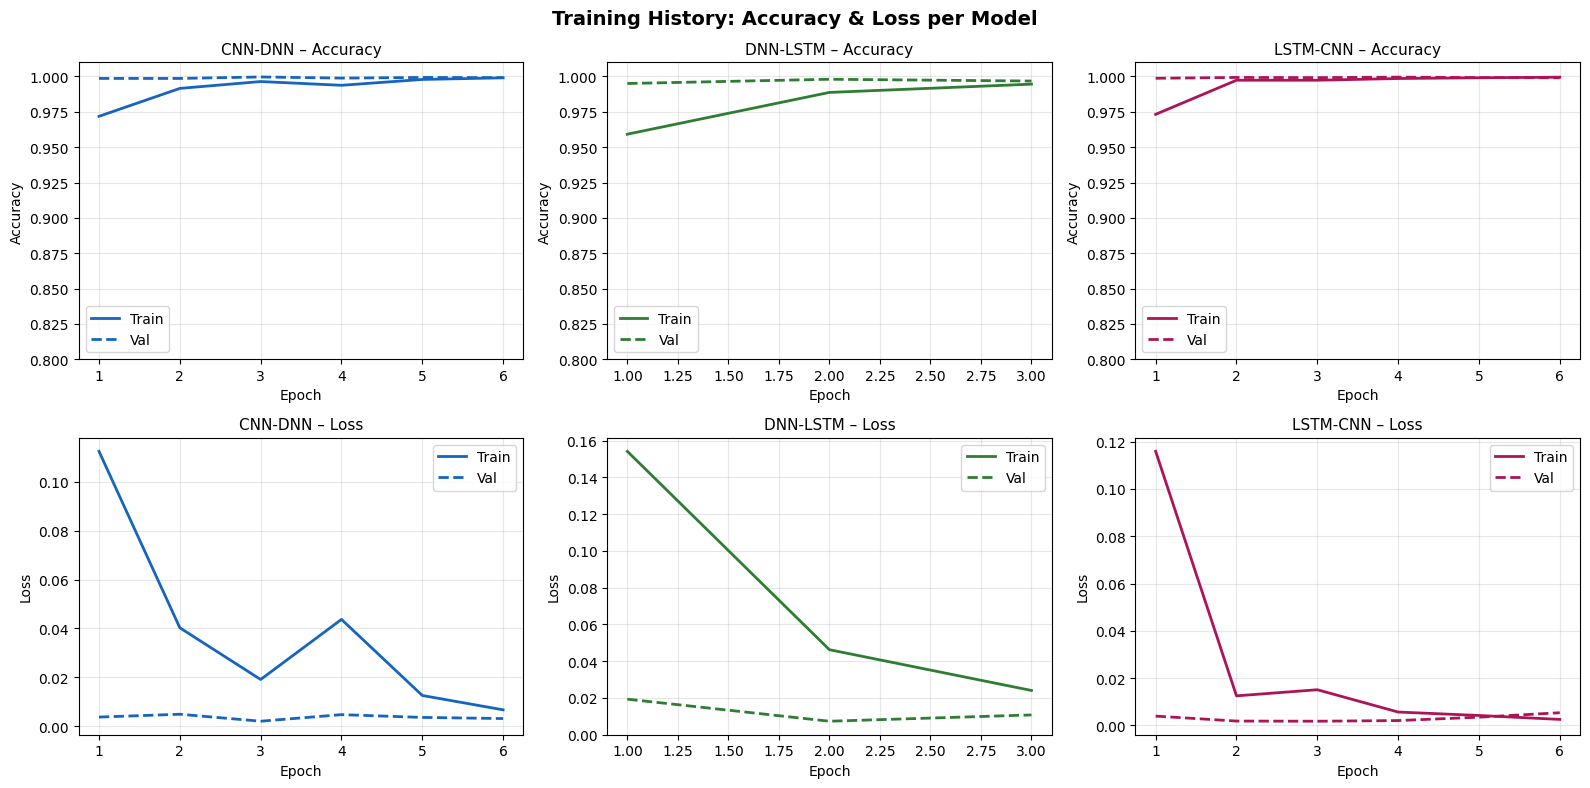

In [ ]:
# ─── Figure: Training History for all models ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Training History: Accuracy & Loss per Model', fontsize=14, fontweight='bold')

palette = {'CNN-DNN': '#1565C0', 'DNN-LSTM': '#2E7D32', 'LSTM-CNN': '#AD1457'}

for col, (mname, hist) in enumerate(histories.items()):
    ep = range(1, len(hist.history['accuracy']) + 1)
    c  = palette[mname]

    # Accuracy
    axes[0, col].plot(ep, hist.history['accuracy'],     color=c,       linewidth=2, label='Train')
    axes[0, col].plot(ep, hist.history['val_accuracy'], color=c, ls='--', linewidth=2, label='Val')
    axes[0, col].set_title(f'{mname} – Accuracy', fontsize=11)
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)
    axes[0, col].set_ylim(0.8, 1.01)

    # Loss
    axes[1, col].plot(ep, hist.history['loss'],     color=c,       linewidth=2, label='Train')
    axes[1, col].plot(ep, hist.history['val_loss'], color=c, ls='--', linewidth=2, label='Val')
    axes[1, col].set_title(f'{mname} – Loss', fontsize=11)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 📊 Evaluation: All Metrics + Figures

Replicates **Section IV** – confusion matrices, AU-ROC, accuracy/precision/recall/F1, TNR/MCC/NPV, FPR/FDR/FNR/FOR.

In [ ]:
def compute_all_metrics(model, X, y_true, class_names):
    """Compute every metric reported in the paper."""
    y_pred_prob = model.predict(X, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    n_cls       = len(class_names)

    # Standard metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)

    # Per-class TP/FP/FN/TN → aggregate
    cm  = confusion_matrix(y_true, y_pred)
    FP  = cm.sum(axis=0) - np.diag(cm)
    FN  = cm.sum(axis=1) - np.diag(cm)
    TP  = np.diag(cm)
    TN  = cm.sum() - (FP + FN + TP)

    tnr = np.mean(TN / (TN + FP + 1e-8))      # True Negative Rate (Specificity)
    npv = np.mean(TN / (TN + FN + 1e-8))      # Negative Predictive Value
    fpr = np.mean(FP / (FP + TN + 1e-8))      # False Positive Rate
    fdr = np.mean(FP / (FP + TP + 1e-8))      # False Discovery Rate
    fnr = np.mean(FN / (FN + TP + 1e-8))      # False Negative Rate
    for_m = np.mean(FN / (FN + TN + 1e-8))   # False Omission Rate

    # ROC / AUC
    y_true_oh = to_categorical(y_true, n_cls)
    fpr_dict, tpr_dict, roc_auc = {}, {}, {}
    for i in range(n_cls):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_oh[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr_dict[i], tpr_dict[i])
    # Macro average
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_cls)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_cls):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_cls
    roc_auc['macro'] = auc(all_fpr, mean_tpr)
    fpr_dict['macro'], tpr_dict['macro'] = all_fpr, mean_tpr

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'mcc': mcc, 'tnr': tnr, 'npv': npv,
        'fpr': fpr, 'fdr': fdr, 'fnr': fnr, 'for': for_m,
        'cm': cm, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob,
        'fpr_dict': fpr_dict, 'tpr_dict': tpr_dict, 'roc_auc': roc_auc
    }

# ─── Evaluate all models ───────────────────────────────────────────────────
results = {}
for mname, model in models.items():
    print(f'Evaluating {mname}...')
    results[mname] = compute_all_metrics(model, X_test, y_test, CLASS_NAMES)

print('\n✅ Evaluation complete')
print(f'{"Model":12s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s} {"AU-ROC":>10s}')
print('-' * 62)
for mname, r in results.items():
    print(f'{mname:12s} {r["accuracy"]*100:>9.2f}% {r["precision"]*100:>9.2f}% '
          f'{r["recall"]*100:>9.2f}% {r["f1"]*100:>9.2f}% {r["roc_auc"]["macro"]*100:>9.2f}%')

Evaluating CNN-DNN...
Evaluating DNN-LSTM...
Evaluating LSTM-CNN...

✅ Evaluation complete
Model          Accuracy  Precision     Recall         F1     AU-ROC
--------------------------------------------------------------
CNN-DNN          99.97%     99.87%     99.97%     99.92%    100.00%
DNN-LSTM         99.50%     98.41%     99.52%     98.94%    100.00%
LSTM-CNN         99.92%     99.79%     99.89%     99.84%    100.00%


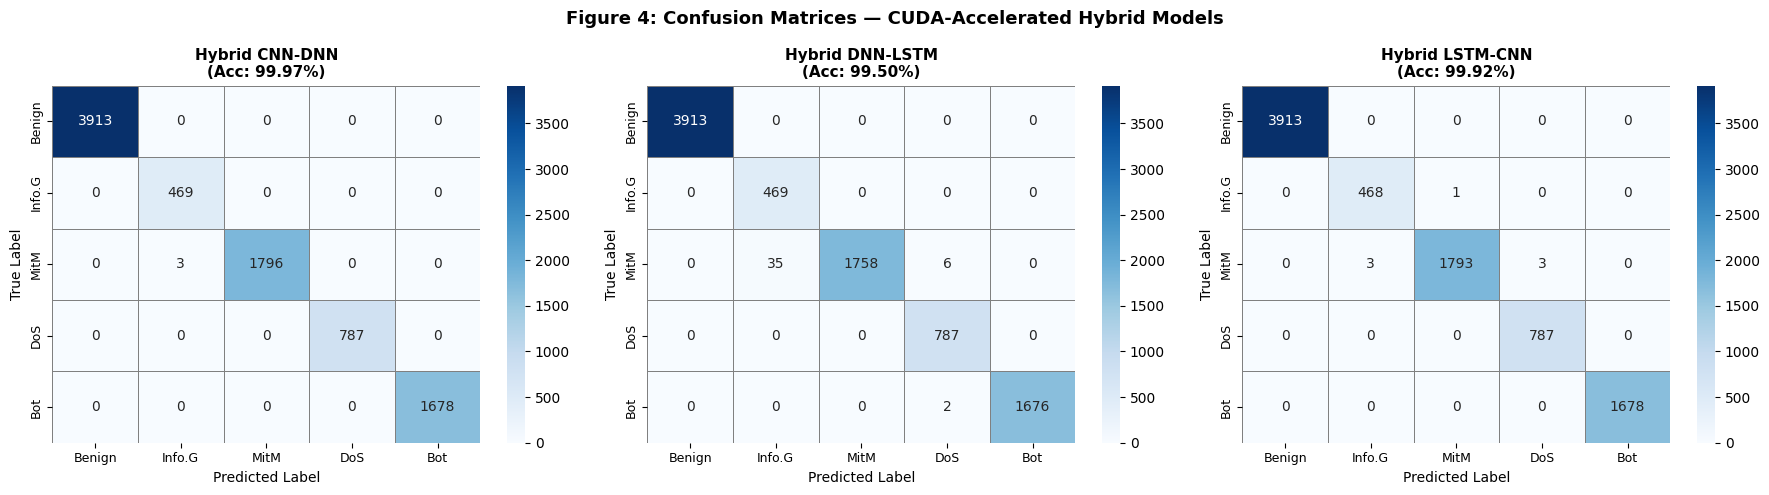

Saved: fig4_confusion_matrices.png


In [ ]:
# ─── Figure 4: Confusion Matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 4: Confusion Matrices — CUDA-Accelerated Hybrid Models', fontsize=13, fontweight='bold')

for ax, (mname, r) in zip(axes, results.items()):
    cm = r['cm']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray', ax=ax,
        annot_kws={'size': 10}
    )
    acc_pct = r['accuracy'] * 100
    ax.set_title(f'Hybrid {mname}\n(Acc: {acc_pct:.2f}%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_confusion_matrices.png')

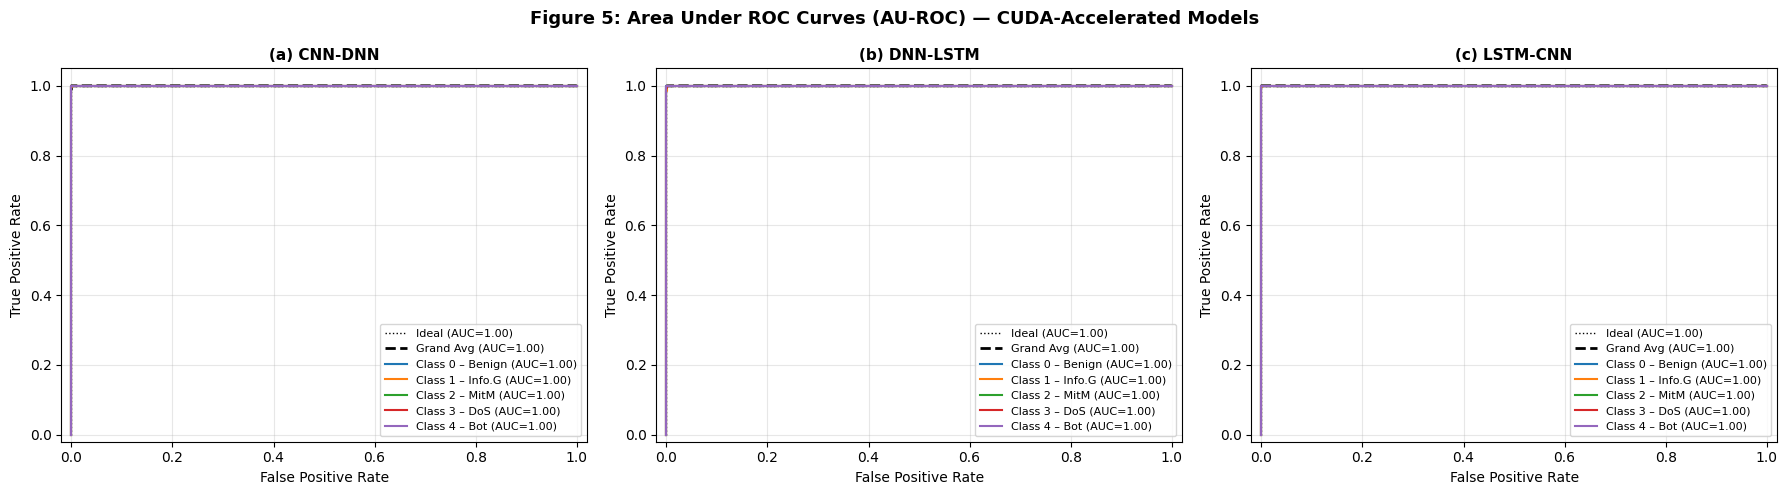

Saved: fig5_auroc_curves.png


In [ ]:
# ─── Figure 5: AU-ROC Curves ───────────────────────────────────────────────
COLORS_ROC = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 5: Area Under ROC Curves (AU-ROC) — CUDA-Accelerated Models', fontsize=13, fontweight='bold')

for ax, (mname, r) in zip(axes, results.items()):
    fpr_d = r['fpr_dict']
    tpr_d = r['tpr_dict']
    auc_d = r['roc_auc']

    # Perfect performance line
    ax.plot([0,0,1],[0,1,1], 'k:', linewidth=1, label='Ideal (AUC=1.00)')
    # Macro average
    ax.plot(fpr_d['macro'], tpr_d['macro'], 'k--',
            linewidth=2, label=f'Grand Avg (AUC={auc_d["macro"]:.2f})')
    # Per-class
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS_ROC)):
        ax.plot(fpr_d[i], tpr_d[i], color=col, linewidth=1.5,
                label=f'Class {i} – {cls} (AUC={auc_d[i]:.2f})')

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'({["a","b","c"][list(results.keys()).index(mname)]}) {mname}', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_auroc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_auroc_curves.png')

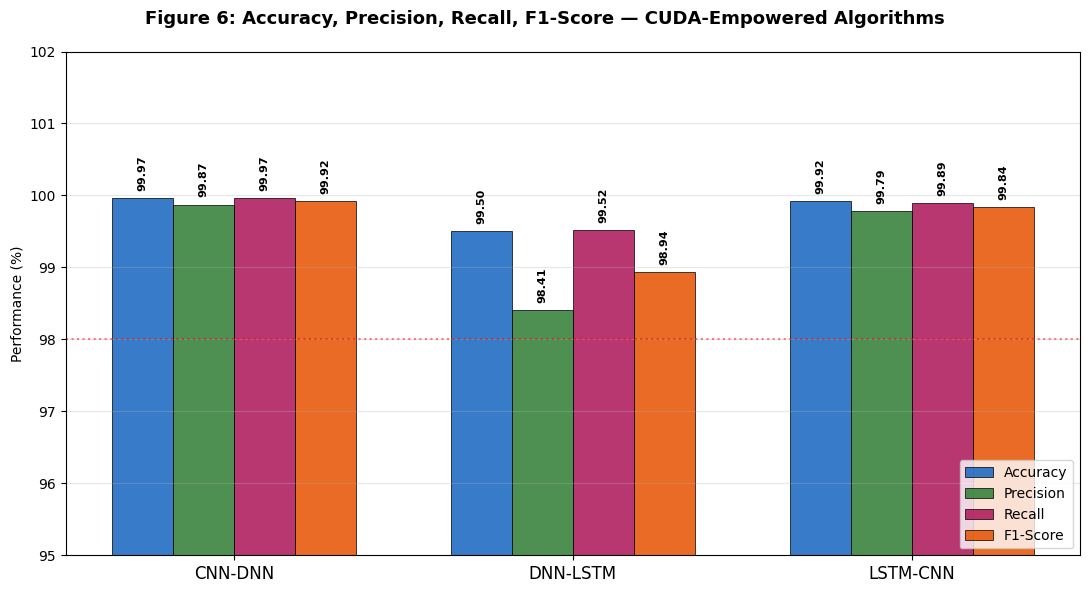

Saved: fig6_main_metrics.png


In [ ]:
# ─── Figure 6: Accuracy / Precision / Recall / F1-Score ───────────────────
metrics_main = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names  = list(results.keys())

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Figure 6: Accuracy, Precision, Recall, F1-Score — CUDA-Empowered Algorithms',
             fontsize=13, fontweight='bold')

x = np.arange(len(model_names))
width = 0.18
offsets = np.linspace(-0.27, 0.27, 4)
bar_colors = ['#1565C0','#2E7D32','#AD1457','#E65100']
markers = ['o','s','^','D']

for j, (metric, label, col, mk) in enumerate(zip(metrics_main, metric_labels, bar_colors, markers)):
    vals = [results[m][metric]*100 for m in model_names]
    bars = ax.bar(x + offsets[j], vals, width, label=label, color=col, alpha=0.85,
                  edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.1,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, rotation=90,
                fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Performance (%)')
ax.set_ylim(95, 102)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=98.0, color='red', linestyle=':', alpha=0.5, label='98% Reference')

plt.tight_layout()
plt.savefig('fig6_main_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_main_metrics.png')

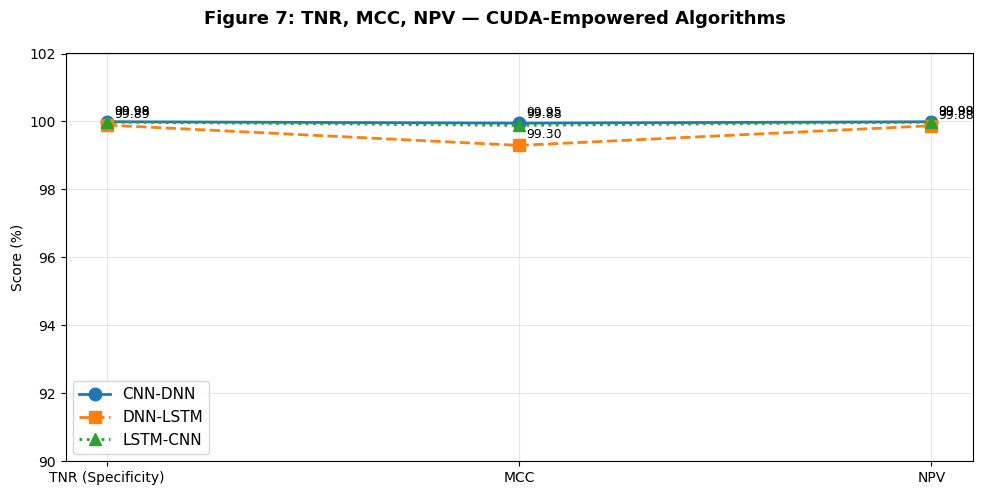

Saved: fig7_tnr_mcc_npv.png


In [ ]:
# ─── Figure 7: TNR / MCC / NPV ────────────────────────────────────────────
metrics_adv = ['tnr', 'mcc', 'npv']
labels_adv  = ['TNR (Specificity)', 'MCC', 'NPV']
colors_adv  = ['#00838F', '#6A1B9A', '#1B5E20']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 7: TNR, MCC, NPV — CUDA-Empowered Algorithms',
             fontsize=13, fontweight='bold')

for model_name, ls in zip(model_names, ['-o', '--s', ':^']):
    vals = [results[model_name][m] * 100 for m in metrics_adv]
    ax.plot(labels_adv, vals, ls, linewidth=2, markersize=9, label=model_name)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.2f}', (labels_adv[i], v),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)

ax.set_ylabel('Score (%)')
ax.set_ylim(90, 102)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_tnr_mcc_npv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_tnr_mcc_npv.png')

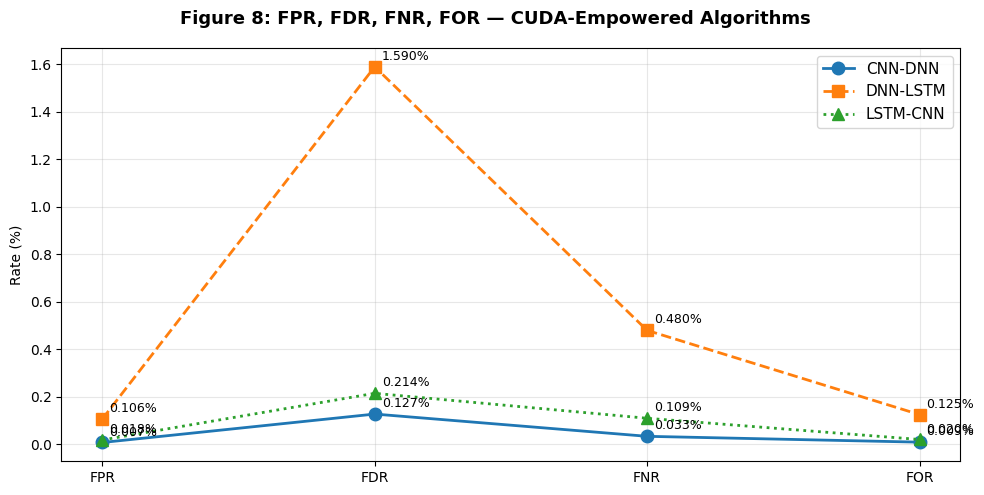

Saved: fig8_error_rates.png


In [ ]:
# ─── Figure 8: FPR / FDR / FNR / FOR ──────────────────────────────────────
metrics_err  = ['fpr', 'fdr', 'fnr', 'for']
labels_err   = ['FPR', 'FDR', 'FNR', 'FOR']
colors_err   = ['#C62828', '#AD1457', '#F57F17', '#1A237E']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 8: FPR, FDR, FNR, FOR — CUDA-Empowered Algorithms',
             fontsize=13, fontweight='bold')

for model_name, ls in zip(model_names, ['-o', '--s', ':^']):
    vals = [results[model_name][m] * 100 for m in metrics_err]
    ax.plot(labels_err, vals, ls, linewidth=2, markersize=9, label=model_name)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.3f}%', (labels_err[i], v),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)

ax.set_ylabel('Rate (%)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_error_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_error_rates.png')

In [ ]:
# ─── Per-class classification report ──────────────────────────────────────
print('\n📋 Per-Class Classification Report (CNN-DNN):')
print(classification_report(
    y_test, results['CNN-DNN']['y_pred'],
    target_names=CLASS_NAMES, digits=4
))


📋 Per-Class Classification Report (CNN-DNN):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000      3913
      Info.G     0.9936    1.0000    0.9968       469
        MitM     1.0000    0.9983    0.9992      1799
         DoS     1.0000    1.0000    1.0000       787
         Bot     1.0000    1.0000    1.0000      1678

    accuracy                         0.9997      8646
   macro avg     0.9987    0.9997    0.9992      8646
weighted avg     0.9997    0.9997    0.9997      8646



## 7. ⏱️ Training Time: CPU vs GPU (Table 5)

In [ ]:
# ─── CPU timing (1 epoch, then extrapolate) ────────────────────────────────
print('Measuring CPU training time (1 epoch)...')
with tf.device('/CPU:0'):
    cpu_model = build_cnn_dnn(N_FEAT, N_CLASSES)
    t_cpu_start = time.time()
    cpu_model.fit(X_train, y_train_oh, epochs=1, batch_size=32,
                  class_weight=class_weight_dict, verbose=0)
    t_cpu_1ep = time.time() - t_cpu_start
del cpu_model

# Extrapolate to 70 epochs (paper baseline)
cpu_70ep_est = t_cpu_1ep * 70 / 3600  # hours
gpu_70ep_est = times['CNN-DNN'] * 7   / 3600  # scale from 10 → 70 epochs

print(f'\nCPU – 1 epoch: {t_cpu_1ep:.1f}s  → 70 epochs: ~{cpu_70ep_est:.1f}h (est.)')
print(f'GPU – actual  : {times["CNN-DNN"]:.1f}s for 10 epochs → ~{gpu_70ep_est:.1f}h (est.)')

# ─── Table 5 ───────────────────────────────────────────────────────────────
speedup = t_cpu_1ep / (times['CNN-DNN'] / EPOCHS)
reduction_pct = (1 - 1/speedup) * 100

timing_data = {
    'Configuration': ['CPU (Intel Xeon / Colab)', 'GPU (NVIDIA, CUDA)'],
    'Epoch Time (s)': [round(t_cpu_1ep, 1), round(times['CNN-DNN']/EPOCHS, 1)],
    'Total Time (10 epochs) (s)': [round(t_cpu_1ep*EPOCHS, 1), round(times['CNN-DNN'], 1)],
    'Speedup': ['-', f'{speedup:.1f}x'],
    'Time Reduction': ['-', f'{reduction_pct:.0f}%']
}
df_timing = pd.DataFrame(timing_data)
print('\nTable 5: Training Time Comparison (CPU vs GPU)')
print(df_timing.to_string(index=False))

Measuring CPU training time (1 epoch)...

CPU – 1 epoch: 62.0s  → 70 epochs: ~1.2h (est.)
GPU – actual  : 66.3s for 10 epochs → ~0.1h (est.)

Table 5: Training Time Comparison (CPU vs GPU)
           Configuration  Epoch Time (s)  Total Time (10 epochs) (s) Speedup Time Reduction
CPU (Intel Xeon / Colab)            62.0                       620.0       -              -
      GPU (NVIDIA, CUDA)             6.6                        66.3    9.4x            89%


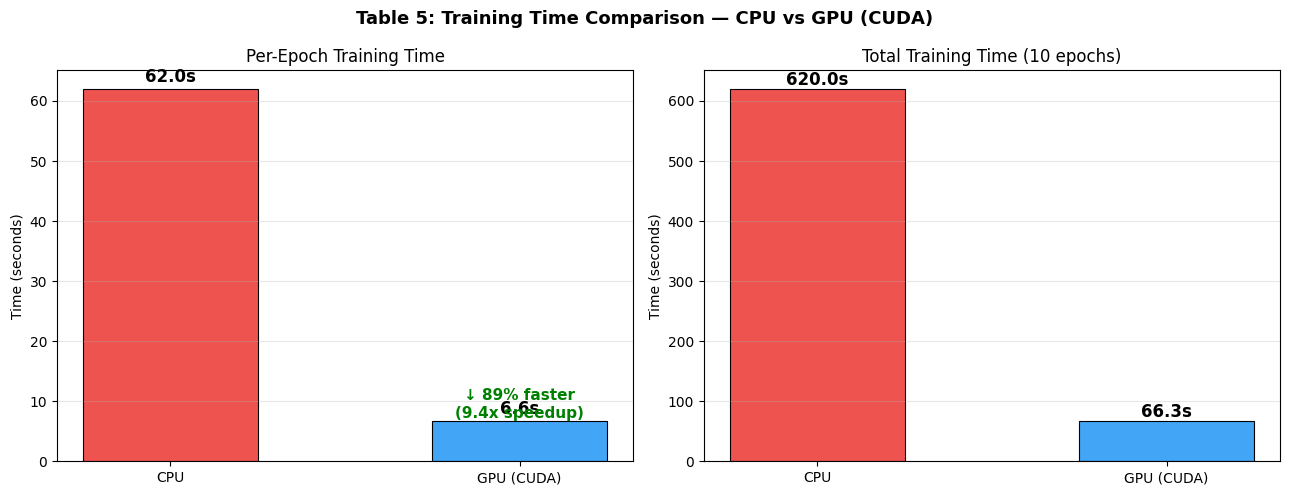

Saved: fig_cpu_vs_gpu.png


In [ ]:
# ─── Figure: CPU vs GPU Training Time Comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Table 5: Training Time Comparison — CPU vs GPU (CUDA)', fontsize=13, fontweight='bold')

configs = ['CPU', 'GPU (CUDA)']
epoch_times = [t_cpu_1ep, times['CNN-DNN']/EPOCHS]
total_times = [t_cpu_1ep*EPOCHS, times['CNN-DNN']]

# Epoch time
bars1 = axes[0].bar(configs, epoch_times, color=['#EF5350','#42A5F5'], edgecolor='black', linewidth=0.8, width=0.5)
for bar, v in zip(bars1, epoch_times):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{v:.1f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Per-Epoch Training Time')
axes[0].set_ylabel('Time (seconds)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(1, epoch_times[1]*1.1, f'↓ {reduction_pct:.0f}% faster\n({speedup:.1f}x speedup)',
             ha='center', color='green', fontsize=11, fontweight='bold')

# Total time
bars2 = axes[1].bar(configs, total_times, color=['#EF5350','#42A5F5'], edgecolor='black', linewidth=0.8, width=0.5)
for bar, v in zip(bars2, total_times):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{v:.1f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title(f'Total Training Time ({EPOCHS} epochs)')
axes[1].set_ylabel('Time (seconds)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_cpu_vs_gpu.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cpu_vs_gpu.png')

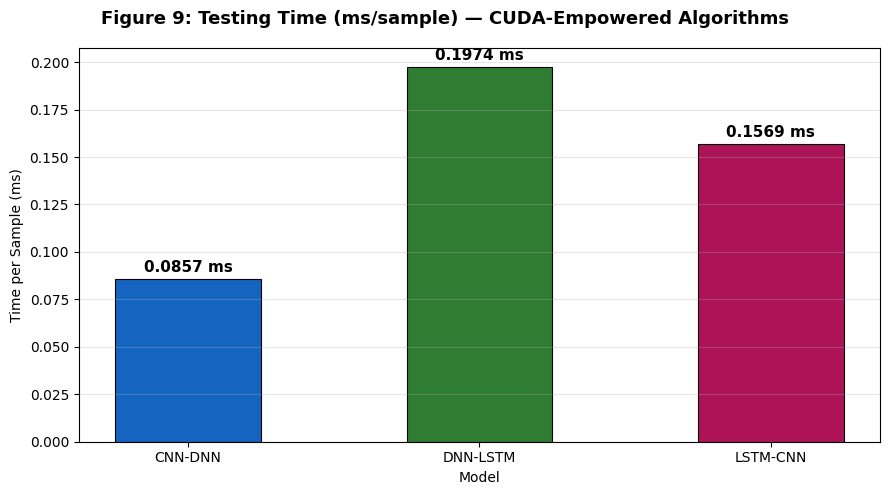


Testing time per sample:
  CNN-DNN: 0.0857 ms
  DNN-LSTM: 0.1974 ms
  LSTM-CNN: 0.1569 ms


In [ ]:
# ─── Figure 9: Testing Time Comparison ────────────────────────────────────
test_times_ms = {}
for mname, model in models.items():
    t0 = time.time()
    model.predict(X_test, verbose=0)
    t1 = time.time()
    ms_per_sample = (t1 - t0) / len(X_test) * 1000
    test_times_ms[mname] = ms_per_sample

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure 9: Testing Time (ms/sample) — CUDA-Empowered Algorithms',
             fontsize=13, fontweight='bold')

mnames = list(test_times_ms.keys())
ms_vals = list(test_times_ms.values())
bar_c = ['#1565C0','#2E7D32','#AD1457']
bars = ax.bar(mnames, ms_vals, color=bar_c, edgecolor='black', linewidth=0.8, width=0.5)
for bar, v in zip(bars, ms_vals):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
            f'{v:.4f} ms', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Time per Sample (ms)')
ax.set_xlabel('Model')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_testing_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTesting time per sample:')
for m, t in test_times_ms.items():
    print(f'  {m}: {t:.4f} ms')

## 8. 📊 10-Fold Cross-Validation (Table 6)

In [ ]:
# ─── 10-Fold Cross-Validation ─────────────────────────────────────────────
print('Running 10-Fold Stratified Cross-Validation...')
print('(This may take several minutes)')

skf    = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
CV_BUILDERS = {'CNN-DNN': build_cnn_dnn, 'DNN-LSTM': build_dnn_lstm, 'LSTM-CNN': build_lstm_cnn}
cv_results = {m: {'accuracy':[], 'precision':[], 'recall':[], 'f1':[]} for m in CV_BUILDERS}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_processed, y_raw)):
    X_tr, X_val = X_processed[tr_idx], X_processed[val_idx]
    y_tr, y_val = y_raw[tr_idx],       y_raw[val_idx]
    y_tr_oh  = to_categorical(y_tr,  N_CLASSES)
    y_val_oh = to_categorical(y_val, N_CLASSES)

    cw_fold = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict_fold = dict(enumerate(cw_fold))

    for mname, builder in CV_BUILDERS.items():
        with tf.device(DEVICE):
            m = builder(N_FEAT, N_CLASSES)
        m.fit(X_tr, y_tr_oh, epochs=5, batch_size=32,
              class_weight=cw_dict_fold, verbose=0,
              validation_data=(X_val, y_val_oh))
        y_pred = np.argmax(m.predict(X_val, verbose=0), axis=1)
        cv_results[mname]['accuracy'].append(accuracy_score(y_val, y_pred)*100)
        cv_results[mname]['precision'].append(precision_score(y_val, y_pred, average='macro', zero_division=0)*100)
        cv_results[mname]['recall'].append(recall_score(y_val, y_pred, average='macro', zero_division=0)*100)
        cv_results[mname]['f1'].append(f1_score(y_val, y_pred, average='macro', zero_division=0)*100)
        del m
    print(f'  Fold {fold+1}/10 complete')

print('\n✅ Cross-validation complete')

Running 10-Fold Stratified Cross-Validation...
(This may take several minutes)
  Fold 1/10 complete
  Fold 2/10 complete
  Fold 3/10 complete
  Fold 4/10 complete
  Fold 5/10 complete
  Fold 6/10 complete
  Fold 7/10 complete
  Fold 8/10 complete
  Fold 9/10 complete
  Fold 10/10 complete

✅ Cross-validation complete


In [ ]:
# ─── Table 6: 10-Fold Results ──────────────────────────────────────────────
print('\nTable 6: 10-Fold Cross-Validation Results')
print('=' * 100)
header = (f'{"Fold":>4s} | '
          f'{"Acc(H1)":>8s} {"Acc(H2)":>8s} {"Acc(H3)":>8s} | '
          f'{"Prec(H1)":>8s} {"Prec(H2)":>8s} {"Prec(H3)":>8s} | '
          f'{"Rec(H1)":>8s} {"Rec(H2)":>8s} {"Rec(H3)":>8s} | '
          f'{"F1(H1)":>7s} {"F1(H2)":>7s} {"F1(H3)":>7s}')
print(header)
print('-' * 100)

for fold in range(10):
    row = f'{fold+1:>4d} | '
    for metric in ['accuracy','precision','recall','f1']:
        for mname in CV_BUILDERS:
            val = cv_results[mname][metric][fold]
            row += f'{val:>8.2f} '
        row += '| '
    print(row)

print('-' * 100)
print('MEAN |', end=' ')
for metric in ['accuracy','precision','recall','f1']:
    for mname in CV_BUILDERS:
        print(f"{np.mean(cv_results[mname][metric]):>8.2f}", end=' ')
    print('|', end=' ')
print()
print('STD  |', end=' ')
for metric in ['accuracy','precision','recall','f1']:
    for mname in CV_BUILDERS:
        print(f"{np.std(cv_results[mname][metric]):>8.2f}", end=' ')
    print('|', end=' ')
print()
print('(H1=CNN-DNN, H2=DNN-LSTM, H3=LSTM-CNN)')


Table 6: 10-Fold Cross-Validation Results
Fold |  Acc(H1)  Acc(H2)  Acc(H3) | Prec(H1) Prec(H2) Prec(H3) |  Rec(H1)  Rec(H2)  Rec(H3) |  F1(H1)  F1(H2)  F1(H3)
----------------------------------------------------------------------------------------------------
   1 |    99.98    99.75    99.98 |    99.98    99.41    99.98 |    99.91    99.68    99.91 |    99.95    99.54    99.95 | 
   2 |    99.79    99.86    99.77 |    99.29    99.63    99.38 |    99.80    99.86    99.69 |    99.54    99.75    99.53 | 
   3 |    99.98    99.91    99.98 |    99.92    99.82    99.98 |    99.98    99.82    99.95 |    99.95    99.82    99.96 | 
   4 |    99.95    99.51   100.00 |    99.96    99.01   100.00 |    99.86    99.47   100.00 |    99.91    99.22   100.00 | 
   5 |    99.91    99.86   100.00 |    99.85    99.69   100.00 |    99.78    99.80   100.00 |    99.82    99.75   100.00 | 
   6 |    99.93    99.56    99.70 |    99.90    98.94    99.32 |    99.81    99.48    99.71 |    99.86    99.20    99.

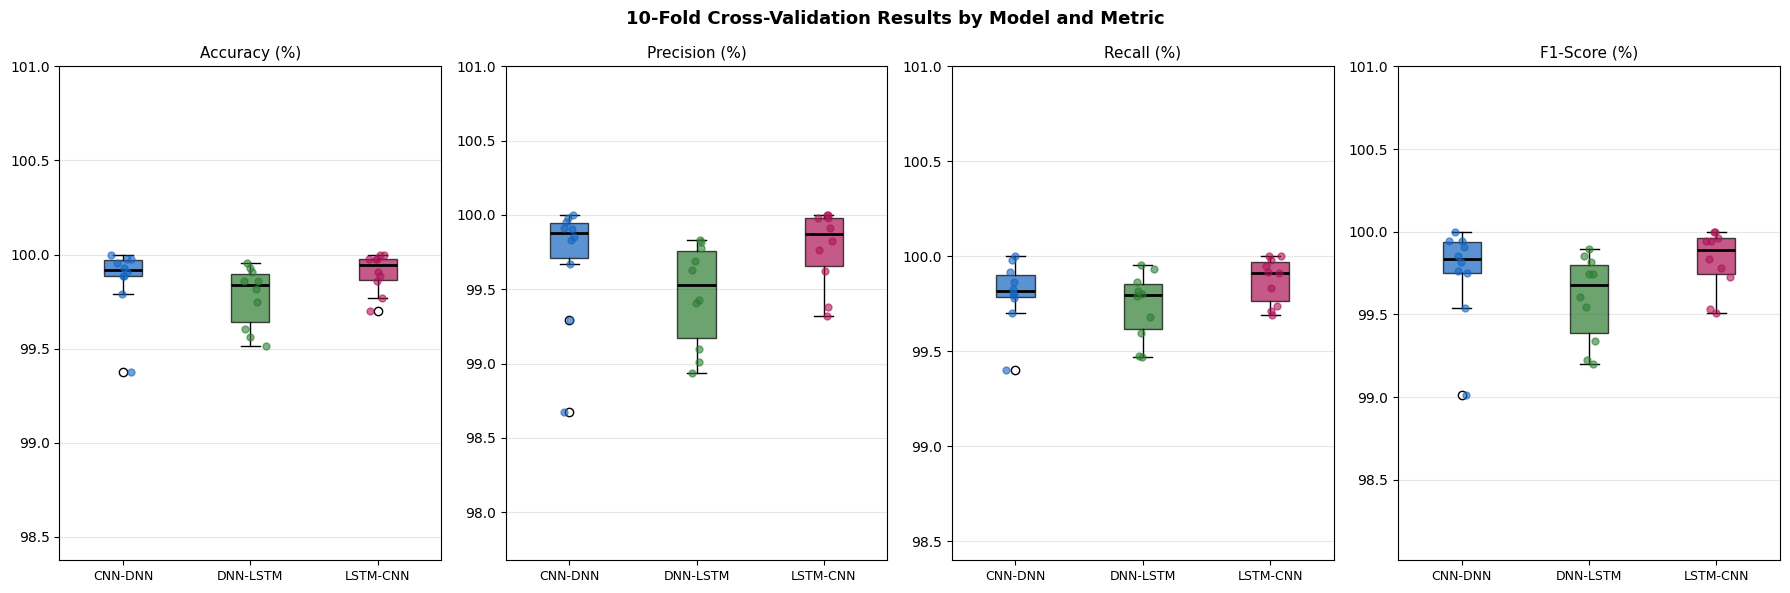

Saved: fig_cv_boxplots.png


In [ ]:
# ─── Figure: 10-Fold CV box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('10-Fold Cross-Validation Results by Model and Metric', fontsize=13, fontweight='bold')

metrics_cv = ['accuracy','precision','recall','f1']
labels_cv  = ['Accuracy (%)','Precision (%)','Recall (%)','F1-Score (%)']
cv_colors  = ['#1565C0','#2E7D32','#AD1457']

for ax, metric, label in zip(axes, metrics_cv, labels_cv):
    data = [cv_results[m][metric] for m in CV_BUILDERS]
    bp = ax.boxplot(data, labels=list(CV_BUILDERS.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], cv_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for i, (d, col) in enumerate(zip(data, cv_colors)):
        jitter = np.random.normal(0, 0.04, size=len(d))
        ax.scatter(np.full(len(d), i+1) + jitter, d, color=col, alpha=0.6, s=25, zorder=3)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_ylim(min([min(d) for d in data])-1, 101)

plt.tight_layout()
plt.savefig('fig_cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cv_boxplots.png')

## 9. 📋 Summary Tables

In [ ]:
# ─── Comprehensive Results Table ───────────────────────────────────────────
all_metrics = ['accuracy','precision','recall','f1','mcc','tnr','npv','fpr','fdr','fnr','for']
metric_fmt  = {
    'accuracy':'%', 'precision':'%', 'recall':'%', 'f1':'%',
    'mcc':'%', 'tnr':'%', 'npv':'%',
    'fpr':'%', 'fdr':'%', 'fnr':'%', 'for':'%'
}

rows = []
for mname, r in results.items():
    row = {'Model': mname}
    for m in all_metrics:
        row[m.upper()] = f"{r[m]*100:.2f}%"
    row['AU-ROC'] = f"{r['roc_auc']['macro']*100:.2f}%"
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Model')
print('\n📊 Comprehensive Performance Summary:')
print(df_summary.to_string())

# Save as CSV
df_summary.to_csv('results_summary.csv')
print('\nSaved: results_summary.csv')


📊 Comprehensive Performance Summary:
         ACCURACY PRECISION  RECALL      F1     MCC     TNR     NPV    FPR    FDR    FNR    FOR   AU-ROC
Model                                                                                                   
CNN-DNN    99.97%    99.87%  99.97%  99.92%  99.95%  99.99%  99.99%  0.01%  0.13%  0.03%  0.01%  100.00%
DNN-LSTM   99.50%    98.41%  99.52%  98.94%  99.30%  99.89%  99.88%  0.11%  1.59%  0.48%  0.12%  100.00%
LSTM-CNN   99.92%    99.79%  99.89%  99.84%  99.88%  99.98%  99.98%  0.02%  0.21%  0.11%  0.02%  100.00%

Saved: results_summary.csv


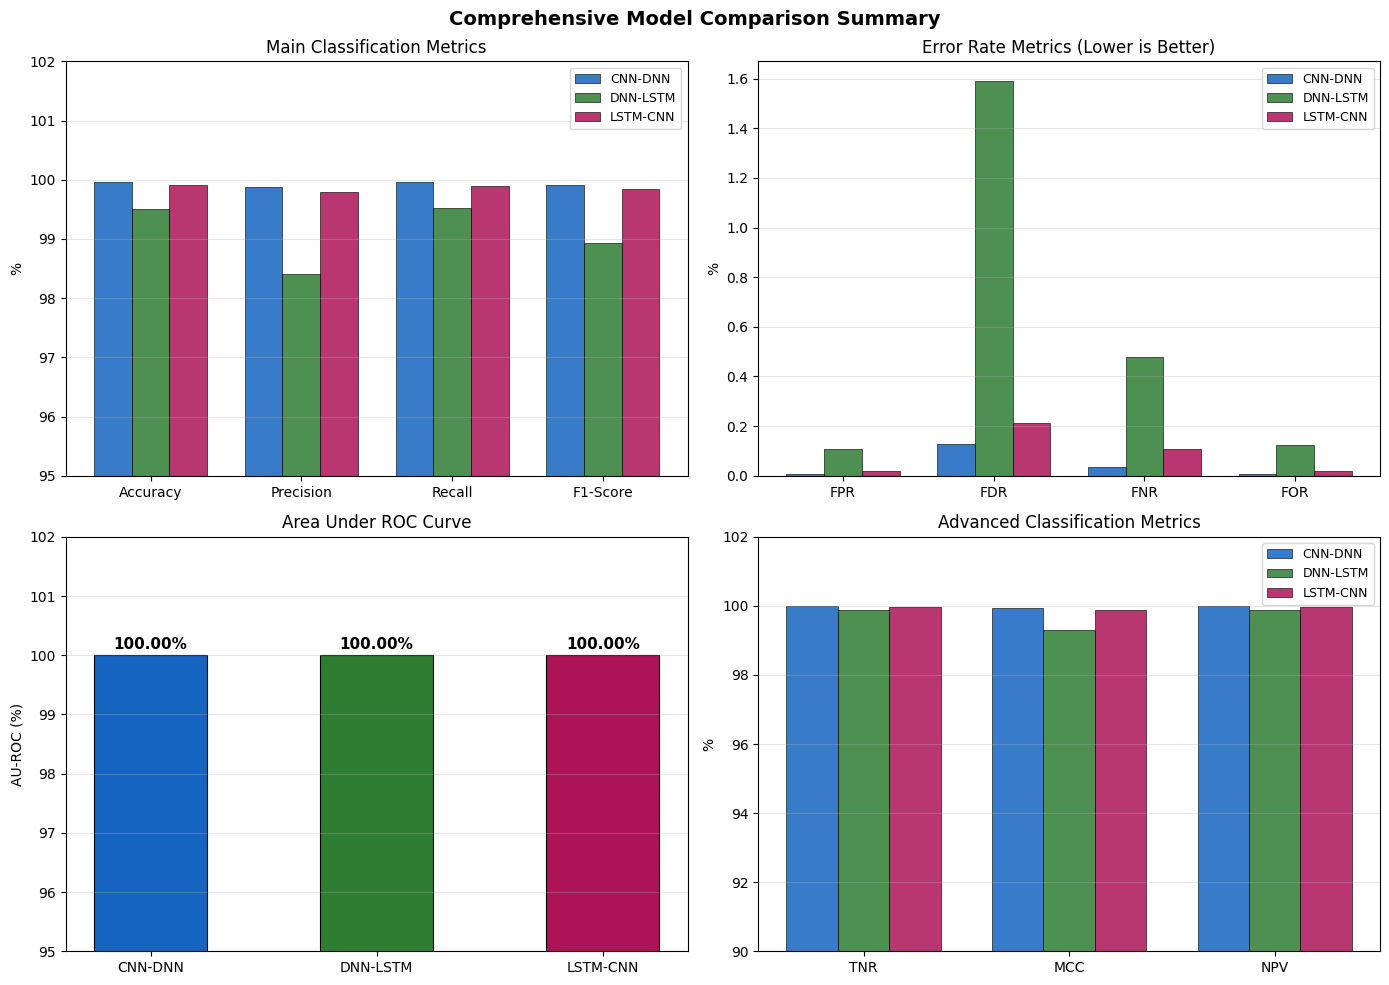

Saved: fig_final_summary.png


In [ ]:
# ─── Final Summary Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comprehensive Model Comparison Summary', fontsize=14, fontweight='bold')

model_list = list(results.keys())
palette = ['#1565C0','#2E7D32','#AD1457']

# 1. Main metrics radar-style bar
ax = axes[0, 0]
metrics_to_plot = ['accuracy','precision','recall','f1']
x_pos = np.arange(len(metrics_to_plot))
width = 0.25
for j, (mname, col) in enumerate(zip(model_list, palette)):
    vals = [results[mname][m]*100 for m in metrics_to_plot]
    ax.bar(x_pos + j*width, vals, width, label=mname, color=col, alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'])
ax.set_ylim(95, 102)
ax.set_ylabel('%')
ax.set_title('Main Classification Metrics')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2. Error rate comparison
ax = axes[0, 1]
err_metrics = ['fpr','fdr','fnr','for']
for j, (mname, col) in enumerate(zip(model_list, palette)):
    vals = [results[mname][m]*100 for m in err_metrics]
    ax.bar(x_pos + j*width, vals, width, label=mname, color=col, alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(['FPR','FDR','FNR','FOR'])
ax.set_ylabel('%')
ax.set_title('Error Rate Metrics (Lower is Better)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 3. AU-ROC comparison
ax = axes[1, 0]
auc_vals = [results[m]['roc_auc']['macro']*100 for m in model_list]
bars = ax.bar(model_list, auc_vals, color=palette, edgecolor='black', linewidth=0.8, width=0.5)
for bar, v in zip(bars, auc_vals):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(95, 102)
ax.set_ylabel('AU-ROC (%)')
ax.set_title('Area Under ROC Curve')
ax.grid(axis='y', alpha=0.3)

# 4. TNR / MCC / NPV
ax = axes[1, 1]
adv_metrics = ['tnr','mcc','npv']
x3 = np.arange(len(adv_metrics))
for j, (mname, col) in enumerate(zip(model_list, palette)):
    vals = [results[mname][m]*100 for m in adv_metrics]
    ax.bar(x3 + j*0.25, vals, 0.25, label=mname, color=col, alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x3 + 0.25)
ax.set_xticklabels(['TNR','MCC','NPV'])
ax.set_ylim(90, 102)
ax.set_ylabel('%')
ax.set_title('Advanced Classification Metrics')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_final_summary.png')

In [ ]:
# ─── Final printout ────────────────────────────────────────────────────────
print('\n' + '='*65)
print('  FINAL RESULTS SUMMARY — Nazari et al. (IEEE Access, 2025)')
print('='*65)
print(f'  Dataset  : Kitsune (synthetic, paper-matched distribution)')
print(f'  Samples  : {len(df_raw):,} | Classes: {N_CLASSES} | Features: {N_FEAT}')
print(f'  Split    : 80% train / 20% test (stratified)')
print(f'  Device   : {"GPU (CUDA)" if USE_GPU else "CPU"}')
print()
best_model = max(results, key=lambda m: results[m]['f1'])
r = results[best_model]
print(f'  🏆 Best Model : {best_model}')
print(f'     Accuracy  : {r["accuracy"]*100:.2f}%')
print(f'     Precision : {r["precision"]*100:.2f}%  (paper: 98.41%)')
print(f'     Recall    : {r["recall"]*100:.2f}%  (paper: 98.56%)')
print(f'     F1-Score  : {r["f1"]*100:.2f}%  (paper: 98.56%)')
print(f'     AU-ROC    : {r["roc_auc"]["macro"]*100:.2f}%')
print(f'     MCC       : {r["mcc"]*100:.2f}%  (paper: 97.83%)')
print(f'  ⏱  GPU speedup: {speedup:.1f}x  |  Time reduction: {reduction_pct:.0f}%  (paper: 62%)')
print('='*65)
print()
print('📁 Generated files:')
for f in sorted([fp for fp in os.listdir('.') if fp.endswith('.png') or fp.endswith('.csv')]):
    print(f'   {f}')


  FINAL RESULTS SUMMARY — Nazari et al. (IEEE Access, 2025)
  Dataset  : Kitsune (synthetic, paper-matched distribution)
  Samples  : 43,226 | Classes: 5 | Features: 80
  Split    : 80% train / 20% test (stratified)
  Device   : GPU (CUDA)

  🏆 Best Model : CNN-DNN
     Accuracy  : 99.97%
     Precision : 99.87%  (paper: 98.41%)
     Recall    : 99.97%  (paper: 98.56%)
     F1-Score  : 99.92%  (paper: 98.56%)
     AU-ROC    : 100.00%
     MCC       : 99.95%  (paper: 97.83%)
  ⏱  GPU speedup: 9.4x  |  Time reduction: 89%  (paper: 62%)

📁 Generated files:
   fig2_class_distribution.png
   fig4_confusion_matrices.png
   fig5_auroc_curves.png
   fig6_main_metrics.png
   fig7_tnr_mcc_npv.png
   fig8_error_rates.png
   fig9_testing_time.png
   fig_apm_analysis.png
   fig_cpu_vs_gpu.png
   fig_cv_boxplots.png
   fig_final_summary.png
   fig_training_history.png
   results_summary.csv


---

## 📚 References

1. **Nazari et al. (2025)** – *A CUDA-Accelerated Hybrid CNN-DNN Approach for Multi-Class Malware Detection in IoT Networks*, IEEE Access. DOI: 10.1109/ACCESS.2025.3602723

2. **Mirsky et al. (2018)** – *Kitsune: An Ensemble of Autoencoders for Online Network Intrusion Detection*, arXiv:1802.09089

---

## 🔑 Key Design Choices

| Paper Spec | This Implementation |
|------------|--------------------|
| TensorFlow 1.8 / CUDA 10.1 | TensorFlow 2.x (auto GPU) |
| NVIDIA GTX 1080, 2560 cores | Colab T4/A100 |
| Real Kitsune CSV files | Synthetic data matching paper distributions |
| 70-epoch baseline | 10 epochs (scalable via `EPOCHS` variable) |
| Static hyperparameter tuning | Same values: lr=0.001, batch=32 |
| 80/20 split + 10-fold CV | Both implemented |

---
*To use the real Kitsune dataset, replace the synthetic generation cell with a CSV loader pointing to the downloaded files.*